In [1]:
import json
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

import os
import glob
import json
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def load_graph_data(json_filepath):
    """Parses a single JSON file into a PyG Data object."""
    with open(json_filepath, 'r') as f:
        graph_data = json.load(f)
        
    num_nodes = graph_data['metadata']['nodes_count']
    edges = graph_data['subgraph_topology']['edge_index']
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_type_indices = graph_data['subgraph_topology']['edge_type_indices']
    edge_attr = torch.tensor(edge_type_indices, dtype=torch.long)
    node_registry = graph_data['node_registry']
    x_features = []
    
    for i in range(num_nodes):
        node_id = str(i)
        features = node_registry[node_id]['features_vector']
        x_features.append(features)
        
    x = torch.tensor(x_features, dtype=torch.float)
    y_targets = graph_data['ml_targets']['y_best_alloc']
    y = torch.tensor(y_targets, dtype=torch.float).unsqueeze(1) 
    
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    return data


def create_dataset_loader(directory_path, batch_size=32, shuffle=True):
    """Iterates over a directory of JSONs to create a PyG DataLoader."""
    data_list = []
    search_pattern = os.path.join(directory_path, "*structured.json")
    json_files = glob.glob(search_pattern)
    
    print(f"Found {len(json_files)} graph files in '{directory_path}'. Loading...")
    
    for filepath in json_files:
        try:
            data = load_graph_data(filepath)
            data_list.append(data)
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            
    loader = DataLoader(data_list, batch_size=batch_size, shuffle=shuffle)
    
    return loader

dataset_folder = './Dataset/dataset_1' 
loader = create_dataset_loader(dataset_folder, batch_size=4, shuffle=True)

for step, batch in enumerate(loader):
    print(f"Batch {step + 1}:")
    print(f" - Number of graphs in batch: {batch.num_graphs}")
    print(f" - Total nodes in batch: {batch.num_nodes}")
    print(f" - Total edges in batch: {batch.num_edges}")
    break # Just printing the first batch to verify

/home/lilian/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 388 graph files in './Dataset/dataset_1'. Loading...
Batch 1:
 - Number of graphs in batch: 4
 - Total nodes in batch: 408
 - Total edges in batch: 2088


Analyzing directed dataset topologies... this might take a moment.

=== Dataset Topology Statistics ===
Nodes per graph : Mean = 93.51 ± 10.29
Edges per graph : Mean = 460.65 ± 68.67
Directed Graph Mean Depth: 4.42 ± 0.39
Directed Graph Max Depth : 10.43 ± 1.70


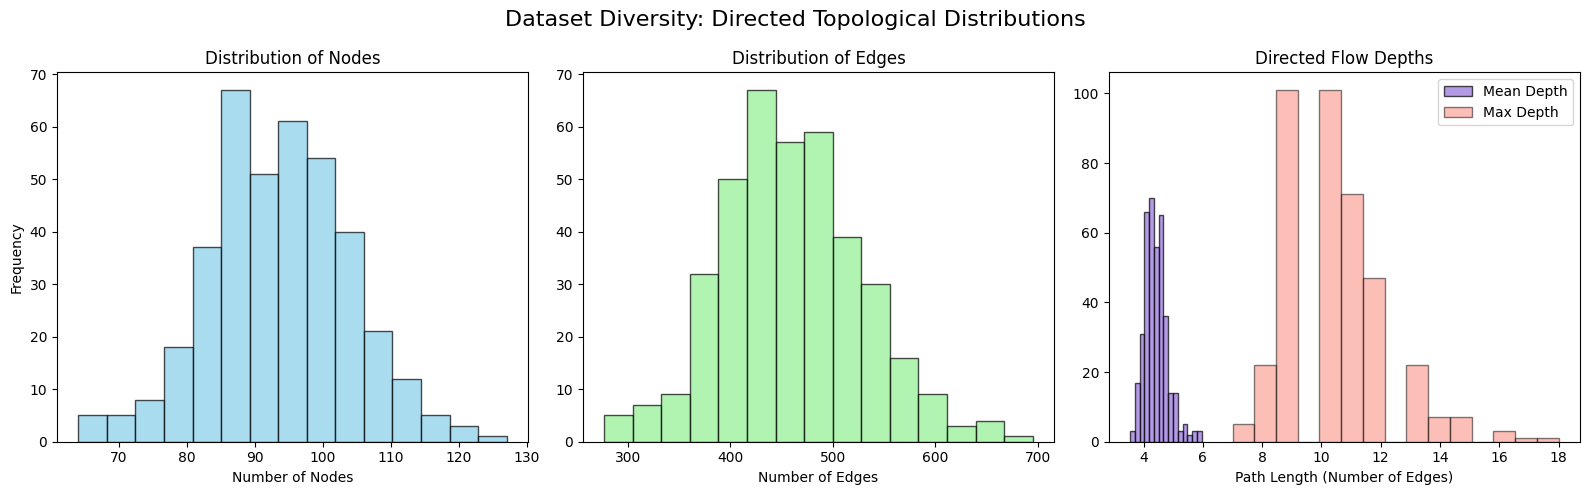

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

# Initialize lists to store our metrics
num_nodes_list = []
num_edges_list = []
mean_depths = []
max_depths = []

print("Analyzing directed dataset topologies... this might take a moment.")

# Iterate through the entire dataset to gather stats
for data in loader.dataset:
    num_nodes_list.append(data.num_nodes)
    num_edges_list.append(data.num_edges)
    
    # Convert to NetworkX, keeping the graph DIRECTED
    G = to_networkx(data, to_undirected=False)
    
    # FIX 1: Remove self-loops (nodes pointing to themselves) which break source/target detection
    G.remove_edges_from(nx.selfloop_edges(G))
    
    sources = [n for n, d in G.in_degree() if d == 0]
    targets = [n for n, d in G.out_degree() if d == 0]
    
    graph_depths = []
    
    # Strategy A: Try finding paths between pure Sources and Targets
    if len(sources) > 0 and len(targets) > 0:
        for s in sources:
            for t in targets:
                if s != t and nx.has_path(G, s, t):
                    graph_depths.append(nx.shortest_path_length(G, s, t))
                    
    # FIX 2: Fallback if the graph is cyclic (no strict sources/targets)
    # Measure the directed shortest path between ALL pairs of reachable nodes
    if len(graph_depths) == 0:
        for s, lengths in nx.shortest_path_length(G):
            for t, length in lengths.items():
                if s != t and length > 0:
                    graph_depths.append(length)
                
    # Store the mean and max depth for this specific graph
    if graph_depths:
        mean_depths.append(np.mean(graph_depths))
        max_depths.append(np.max(graph_depths))

# Convert to numpy arrays for easy math
nodes_arr = np.array(num_nodes_list)
edges_arr = np.array(num_edges_list)
mean_depths_arr = np.array(mean_depths)
max_depths_arr = np.array(max_depths)

# --- 1. Print Summary Statistics ---
print("\n=== Dataset Topology Statistics ===")
print(f"Nodes per graph : Mean = {nodes_arr.mean():.2f} ± {nodes_arr.std():.2f}")
print(f"Edges per graph : Mean = {edges_arr.mean():.2f} ± {edges_arr.std():.2f}")
if len(mean_depths_arr) > 0:
    print(f"Directed Graph Mean Depth: {mean_depths_arr.mean():.2f} ± {mean_depths_arr.std():.2f}")
    print(f"Directed Graph Max Depth : {max_depths_arr.mean():.2f} ± {max_depths_arr.std():.2f}")
else:
    print("Notice: Still could not find any directed paths (graphs might be completely disconnected).")

# --- 2. Plot Distributions ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Diversity: Directed Topological Distributions', fontsize=16)

# Plot Node Distribution
axes[0].hist(nodes_arr, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Nodes')
axes[0].set_xlabel('Number of Nodes')
axes[0].set_ylabel('Frequency')

# Plot Edge Distribution
axes[1].hist(edges_arr, bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Edges')
axes[1].set_xlabel('Number of Edges')

# Plot Depth Distribution (Mean and Max on the same plot)
if len(mean_depths_arr) > 0:
    axes[2].hist(mean_depths_arr, bins=15, color='mediumpurple', edgecolor='black', alpha=0.7, label='Mean Depth')
    axes[2].hist(max_depths_arr, bins=15, color='salmon', edgecolor='black', alpha=0.5, label='Max Depth')
    axes[2].set_title('Directed Flow Depths')
    axes[2].set_xlabel('Path Length (Number of Edges)')
    axes[2].legend()

plt.tight_layout()
plt.show()

In [5]:
import torch
import torch.nn.functional as F
from torch_geometric.nn.models import GCN 

# 1. Initialize the pre-built GCN model
# - in_channels: 6 (matching the length of features_vector)
# - hidden_channels: 16 (number of hidden units, adjustable)
# - num_layers: 2 (number of GCNConv layers)
# - out_channels: 1 (predicting the single y_best_alloc value)
model = GCN(
    in_channels=6,
    hidden_channels=16,
    num_layers=2,
    out_channels=1,
    dropout=0.5
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
def train(loader):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        loss = F.mse_loss(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        
    return total_loss / len(loader.dataset)

for epoch in range(1, 101):
    loss = train(loader)
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

Epoch: 010, Loss: 0.0074
Epoch: 020, Loss: 0.0074
Epoch: 030, Loss: 0.0074
Epoch: 040, Loss: 0.0074


KeyboardInterrupt: 

In [4]:
import torch
import torch.nn.functional as F
from torch_geometric.nn.models import GAT

# 1. Initialize the pre-built GAT model
gat_model = GAT(
    in_channels=6,        # Matches your 6 node features
    hidden_channels=16,
    num_layers=2,
    out_channels=1,       # Predicting y_best_alloc
    heads=2,              # Uses 2 attention heads per layer
    dropout=0.5
)

gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.01)

def train_gat(loader):
    gat_model.train()
    total_loss = 0
    for batch in loader:
        gat_optimizer.zero_grad()
        out = gat_model(batch.x, batch.edge_index)
        loss = F.mse_loss(out, batch.y)
        loss.backward()
        gat_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        
    return total_loss / len(loader.dataset)

print("Starting GAT Training...")
for epoch in range(1, 101):
    loss = train_gat(loader)
    if epoch % 10 == 0:
        print(f'GAT Epoch: {epoch:03d}, Loss: {loss:.4f}')

Starting GAT Training...
GAT Epoch: 010, Loss: 0.0070
GAT Epoch: 020, Loss: 0.0066
GAT Epoch: 030, Loss: 0.0065
GAT Epoch: 040, Loss: 0.0063
GAT Epoch: 050, Loss: 0.0063
GAT Epoch: 060, Loss: 0.0063
GAT Epoch: 070, Loss: 0.0065
GAT Epoch: 080, Loss: 0.0066
GAT Epoch: 090, Loss: 0.0065
GAT Epoch: 100, Loss: 0.0065
